# Sparse GP — Inducing Points

Exact Cholesky is O(N³). For larger datasets, **sparse GPs** approximate the
full kernel matrix using **M ≪ N inducing points**. LightGP's `GPSparse` uses
the variational free-energy (VFE) bound of Titsias (2009).

The trade-off: more inducing points → tighter approximation + more compute.

In [1]:
import os
import sys

# Make the locally-built lightgp importable. Real users install via 'pip install lightgp'.
sys.path.insert(0, os.path.abspath(os.path.join("..", "..", "..", "python")))

import numpy as np
import matplotlib.pyplot as plt
import lightgp as gp

rng = np.random.default_rng(0)
plt.rcParams.update({"figure.figsize": (8, 3.5), "figure.dpi": 90})

## A larger dataset

N = 1500 noisy samples from `sin + cos` mixture.

In [2]:
N = 1500
X = np.sort(rng.uniform(-5, 5, N)).reshape(-1, 1).astype(np.float32)
y = (np.sin(X[:, 0]) + 0.4 * np.cos(2 * X[:, 0])
     + 0.15 * rng.standard_normal(N)).astype(np.float32)
X_test = np.linspace(-5, 5, 400).reshape(-1, 1).astype(np.float32)
print("N =", N)

N = 1500


## Sweep the number of inducing points M

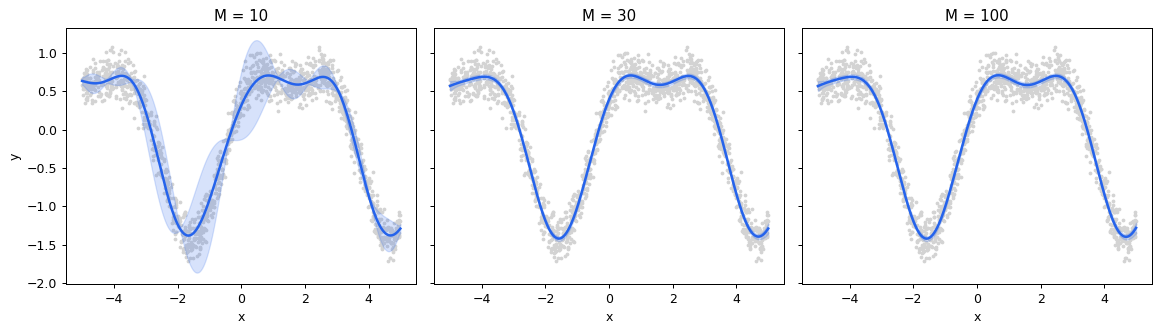

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, M in zip(axes, [10, 30, 100]):
    m = gp.GPSparse(length_scale=1.0, signal_var=1.0, noise_var=0.03)
    m.fit(X, y, num_inducing=M)
    p = m.predict(X_test)
    mu, sd = p["mean"], np.sqrt(np.maximum(p["var"], 0))
    ax.scatter(X[:, 0], y, c="lightgray", s=4, zorder=1)
    ax.fill_between(X_test[:, 0], mu - 2*sd, mu + 2*sd, alpha=0.18, color="#2563EB")
    ax.plot(X_test[:, 0], mu, lw=2, color="#2563EB")
    ax.set_title(f"M = {M}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.tight_layout(); plt.show()

## Picking M

Rules of thumb:

| Regime | M |
|--------|---|
| Quick prototyping | `M ~ sqrt(N)` |
| Production accuracy | `M ~ N / 10`, up to ~200 |
| Memory-bound | Choose the largest M that fits — Sparse storage is O(N + M²) |

For dimensions D > 1, place inducing points throughout the input space.
LightGP initializes by **farthest-point sampling** on the training inputs —
deterministic and a strong default.

## Timing scaling — fit time at fixed M=100

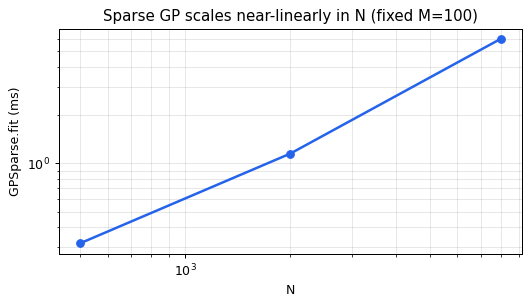

In [4]:
import time
sizes = [500, 2000, 8000]
times = []
for n in sizes:
    Xn = np.sort(rng.uniform(-5, 5, n)).reshape(-1, 1).astype(np.float32)
    yn = (np.sin(Xn[:, 0]) + 0.15 * rng.standard_normal(n)).astype(np.float32)
    m = gp.GPSparse(noise_var=0.03)
    # warmup
    m.fit(Xn, yn, num_inducing=100)
    t0 = time.perf_counter()
    m.fit(Xn, yn, num_inducing=100)
    times.append((time.perf_counter() - t0) * 1000.0)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(sizes, times, "o-", color="#2563EB", lw=2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("N"); ax.set_ylabel("GPSparse.fit (ms)")
ax.set_title("Sparse GP scales near-linearly in N (fixed M=100)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## When to use sparse vs CG vs SKI

- **Any D, N up to ~100k**: `GPSparse` with M = 100–500
- **N up to ~50k, kernel matrix fits in GPU memory**: `Solver.CG` (matrix-free on GPU)
- **N ≫ 100k, D ≤ 3**: `Solver.SKI` (next tutorial)

Sparse GP wins on flexibility — it handles high-D inputs and irregular grids,
which SKI cannot. The next tutorial covers the SKI sweet spot.